# Phase 0 — Explore Your Expenses

Goal: Load YOUR real Supabase data and understand its shape before touching any ML algorithm.

Every chart you produce here is a question the algorithms will answer automatically in later phases.

In [1]:
import sys
sys.path.append('..')

from db import load_expenses, load_monthly_summary
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Replace with your actual user_id from Supabase auth.users
USER_ID = "70cd90c9-163e-4df8-b0ba-de31983f0238"

df = load_expenses(USER_ID)
print(f"Loaded {len(df)} expenses")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print()
print(df.head())

Loaded 840 expenses
Date range: 2025-01-01 → 2026-05-12

     id                               user_id       date description   amount  \
0  4889  70cd90c9-163e-4df8-b0ba-de31983f0238 2025-01-01       maggi    92.00   
1  4890  70cd90c9-163e-4df8-b0ba-de31983f0238 2025-01-01      Paneer   228.00   
2  4891  70cd90c9-163e-4df8-b0ba-de31983f0238 2025-01-01      Swiggy  2243.00   
3  4893  70cd90c9-163e-4df8-b0ba-de31983f0238 2025-01-01     Savings  5000.00   
4  4895  70cd90c9-163e-4df8-b0ba-de31983f0238 2025-01-01       Excel   588.82   

       category  is_auto_generated source_type  source_id iphone_import_id  \
0  HOME Purpose              False        None        NaN             None   
1  HOME Purpose              False        None        NaN             None   
2  HOME Purpose              False        None        NaN             None   
3       Savings              False        None        NaN             None   
4  MonthlyBills              False        None        NaN         

## 1. Your expenses table IS a matrix

Shape = (number of expenses, number of columns). Every ML algorithm operates on this matrix.

In [2]:
print("Matrix shape:", df.shape)
print("Columns (features):", df.columns.tolist())
print()
print("One expense row = one vector:")
print(df[['date', 'description', 'amount', 'category']].iloc[0])

Matrix shape: (840, 14)
Columns (features): ['id', 'user_id', 'date', 'description', 'amount', 'category', 'is_auto_generated', 'source_type', 'source_id', 'iphone_import_id', 'created_at', 'note', 'payment_source', 'month']

One expense row = one vector:
date           2025-01-01 00:00:00
description                  maggi
amount                        92.0
category              HOME Purpose
Name: 0, dtype: object


## 2. Monthly spending totals

month
2025-01    187710.82
2025-02    205871.00
2025-03    185346.00
2025-04    160816.80
2025-05    162832.32
2025-06    150170.82
2025-07    154463.00
2025-08    213061.00
2025-09    177719.62
2025-10    204834.00
2025-11    132051.00
2025-12    201553.10
2026-01    270543.00
2026-02    191296.36
2026-03    179228.90
2026-04    350083.35
2026-05    231907.95
Freq: M, Name: amount, dtype: float64


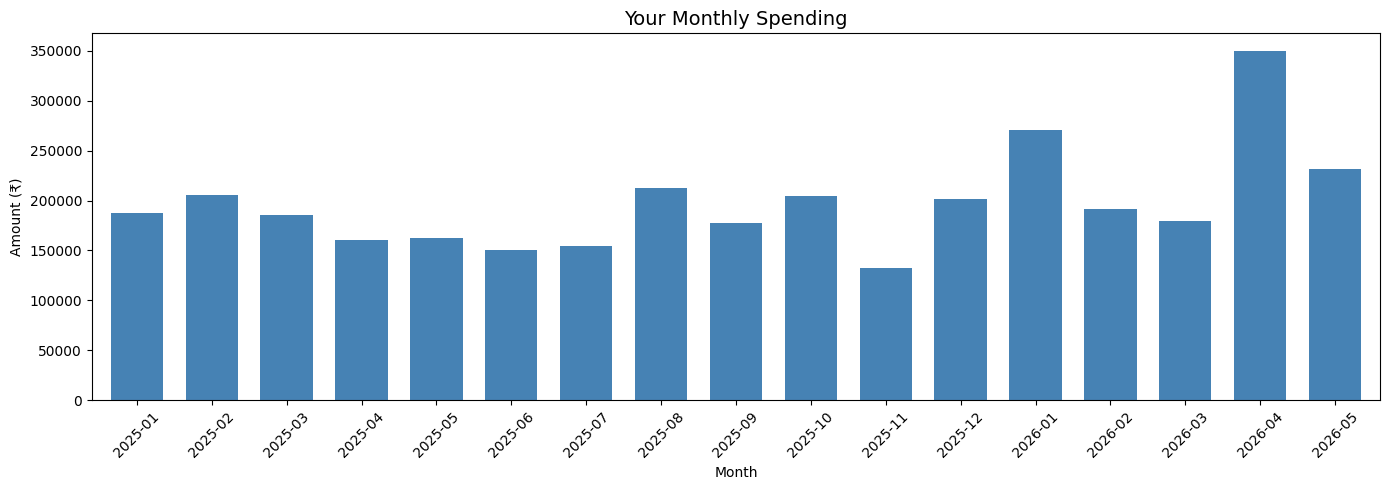


Mean monthly spend: ₹197,617
Std deviation:      ₹51,304
Highest month:      2026-04 (₹350,083)
Lowest month:       2025-11 (₹132,051)


In [3]:
monthly = df.groupby('month')['amount'].sum().sort_index()
print(monthly)

plt.figure(figsize=(14, 5))
monthly.plot(kind='bar', color='steelblue', width=0.7)
plt.title('Your Monthly Spending', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nMean monthly spend: ₹{monthly.mean():,.0f}")
print(f"Std deviation:      ₹{monthly.std():,.0f}")
print(f"Highest month:      {monthly.idxmax()} (₹{monthly.max():,.0f})")
print(f"Lowest month:       {monthly.idxmin()} (₹{monthly.min():,.0f})")

## 3. Spending by category

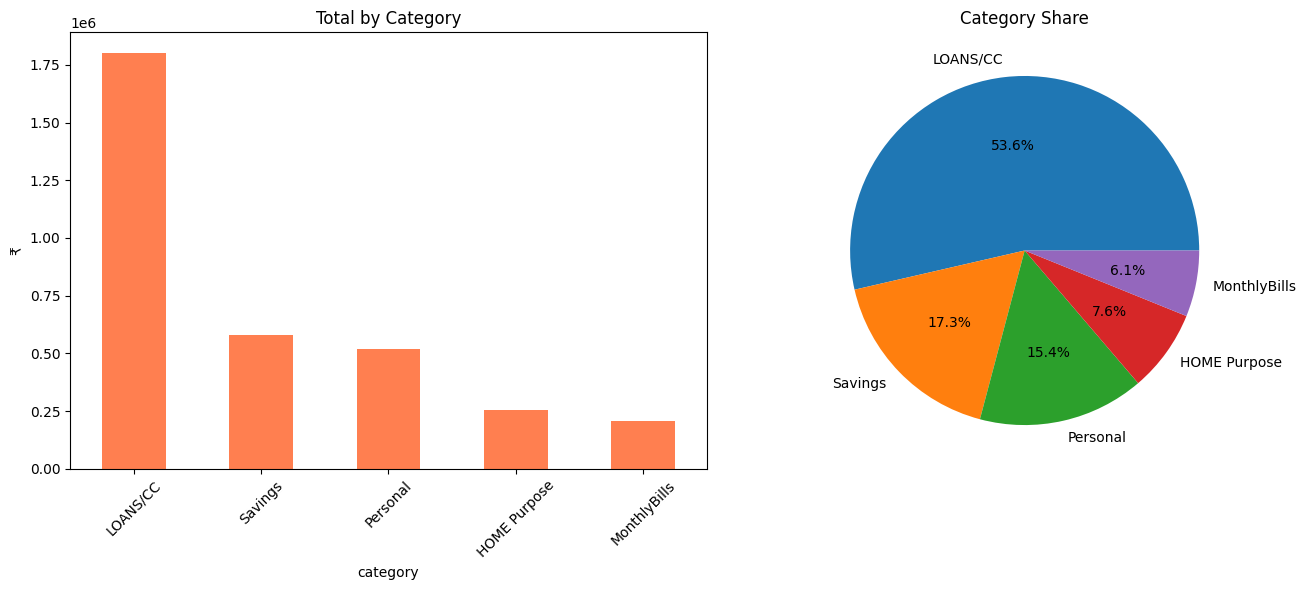

In [4]:
by_cat = df.groupby('category')['amount'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

by_cat.plot(kind='bar', ax=ax1, color='coral')
ax1.set_title('Total by Category')
ax1.set_ylabel('₹')
ax1.tick_params(axis='x', rotation=45)

by_cat.plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_title('Category Share')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

## 4. Your spending distribution (THE key concept for Phase 2)

This histogram shows the **shape** of your individual expense amounts.
- The cluster in the centre = your normal spending range
- The long tail on the right = rare high-value transactions

In Phase 2, we'll automatically flag anything too far from the centre as an anomaly.

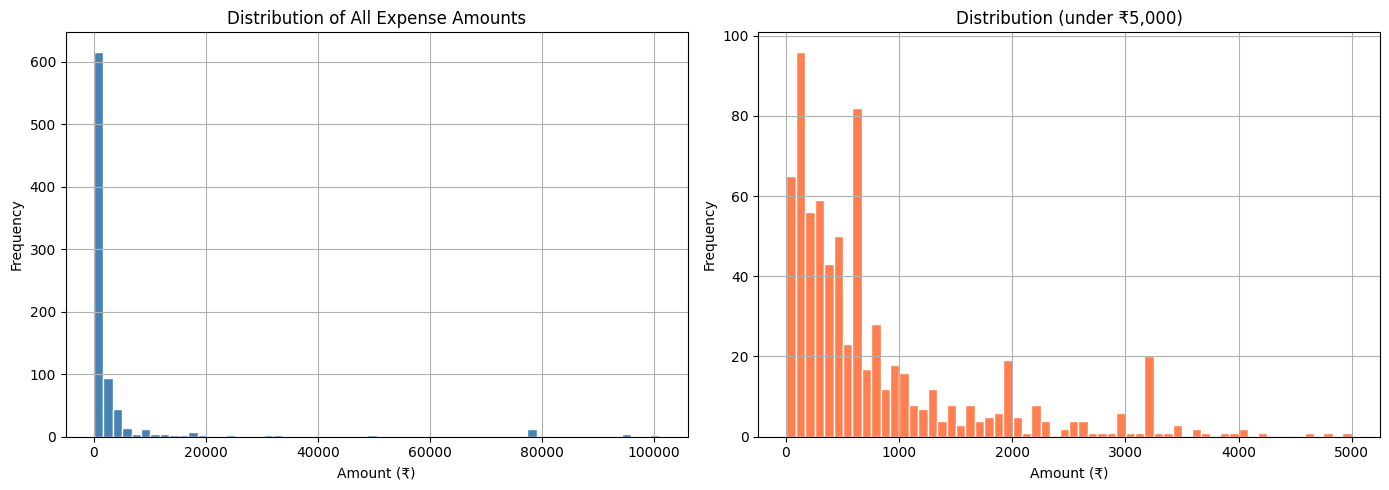

numpy array shape: (840,)
Mean:   ₹3,999.4
Median: ₹619.0
Std:    ₹13,301.3
Min:    ₹5.0
Max:    ₹101,000.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All expenses
df['amount'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of All Expense Amounts')
axes[0].set_xlabel('Amount (₹)')
axes[0].set_ylabel('Frequency')

# Under ₹5000 (removes extreme outliers so you can see the bulk)
df[df['amount'] < 5000]['amount'].hist(bins=60, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribution (under ₹5,000)')
axes[1].set_xlabel('Amount (₹)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# numpy math on this distribution
amounts = df['amount'].values   # this is a numpy ARRAY (1D vector)
print("numpy array shape:", amounts.shape)
print(f"Mean:   ₹{np.mean(amounts):,.1f}")
print(f"Median: ₹{np.median(amounts):,.1f}")
print(f"Std:    ₹{np.std(amounts):,.1f}")
print(f"Min:    ₹{np.min(amounts):,.1f}")
print(f"Max:    ₹{np.max(amounts):,.1f}")

## 5. numpy vs Python loop — see the speedup yourself

In [6]:
import time

# Python loop
start = time.perf_counter()
total_py = 0
for a in df['amount']:
    total_py += a
py_time = time.perf_counter() - start

# numpy
start = time.perf_counter()
total_np = np.sum(df['amount'].values)
np_time = time.perf_counter() - start

print(f"Python loop: {py_time*1000:.3f}ms  → total ₹{total_py:,.0f}")
print(f"numpy:       {np_time*1000:.3f}ms  → total ₹{total_np:,.0f}")
if np_time > 0:
    print(f"numpy is {py_time/np_time:.0f}× faster")
print()
print("Both give the same answer — numpy just gets there faster.")
print("With millions of rows (neural net training), this difference is what makes ML possible.")

Python loop: 0.365ms  → total ₹3,359,489
numpy:       0.159ms  → total ₹3,359,489
numpy is 2× faster

Both give the same answer — numpy just gets there faster.
With millions of rows (neural net training), this difference is what makes ML possible.


## Phase 0 complete ✓

You've:
- Loaded your real Supabase data into a pandas DataFrame (a matrix)
- Plotted your monthly spending (future: Phase 1 adds a trend line)
- Seen your spending distribution (future: Phase 2 flags the outliers)
- Timed numpy vs Python loop (the reason neural nets can exist)

Next: **Phase 1 — Linear Regression**. We'll draw a trend line through your monthly totals and forecast your year-end balance.

In [9]:
import numpy as np

# Monthly totals (already computed in Cell 3)
monthly = df.groupby('month')['amount'].sum().sort_index()

# month number: 1, 2, 3, ...
x = np.arange(1, len(monthly) + 1)
y = monthly.values

# correlation
r = np.corrcoef(x, y)[0, 1]
print(f"Months of data: {len(monthly)}")
print(f"Correlation r = {r:.3f}")

if r > 0.5:   print("Strong positive — spending is clearly trending up")
elif r > 0.1: print("Weak positive — slight upward trend")
elif r < -0.5: print("Strong negative — spending is trending down")
else:          print("Near zero — no clear time trend")

Months of data: 17
Correlation r = 0.485
Weak positive — slight upward trend


In [10]:
# Filter out Savings and LOANS/CC
df_clean = df[~df['category'].isin(['Savings', 'LOANS/CC'])]

monthly_clean = df_clean.groupby('month')['amount'].sum().sort_index()
x2 = np.arange(1, len(monthly_clean) + 1)
y2 = monthly_clean.values

r_clean = np.corrcoef(x2, y2)[0, 1]
print(f"Original r  = {r:.3f}  (all categories)")
print(f"Filtered r  = {r_clean:.3f}  (no Savings/LOANS)")
print(f"Difference  = {r_clean - r:+.3f}")

Original r  = 0.485  (all categories)
Filtered r  = -0.262  (no Savings/LOANS)
Difference  = -0.747


In [13]:
df_nosavings = df[df['category'] != 'Savings']

monthly_nosavings = df_nosavings.groupby('month')['amount'].sum().sort_index()
x3 = np.arange(1, len(monthly_nosavings) + 1)
y3 = monthly_nosavings.values

r_nosavings = np.corrcoef(x3, y3)[0, 1]
print(f"Original (all):          r = {r:.3f}")
print(f"Exclude Savings only:    r = {r_nosavings:.3f}")
print(f"Exclude Savings+LOANS:   r = {r_clean:.3f}")


Original (all):          r = 0.485
Exclude Savings only:    r = 0.298
Exclude Savings+LOANS:   r = -0.262
